In [104]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process

from tqdm.auto import tqdm
import multiprocessing as mp
from scipy.stats import norm
from scipy.special import ndtri

## Load participant data and meta files 

In [2]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


In [3]:
def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

In [65]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/localization_check_data/localization_check')
part_results = sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/localization_check/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))

# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file


dfs = []
for result_file in part_results:

    part_name = result_file.stem
    # remove space 
    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    # get digits in string pattern participant_xxx_ or participant_XXX. 
    part_ix = int(re.search(r'\d+', part_name).group())
    part_name_str = f"participant_{part_ix:03d}"
    manifest_file = manifest_dict[part_name_str]
    # part_df = pd.read_csv(result_file)
    # part_df = part_df
    part_df = util_process.get_part_df_loc_check(result_file)
    manifest_df = util_process.get_manifest_df(manifest_file)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='left')
    part_df['participant'] = part_name_str
    part_df['task'] = part_df['target_loc'].apply(lambda x: 'direction' if isinstance(x, list) else 'overlap')
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)
results_df.loc[results_df.task == 'direction', "direction_label"] = results_df.loc[results_df.task == 'direction', ['target_elev', 'distractor_elev']].apply(lambda x: int(~(x[0] > x[1])), axis=1) # negate to match jspsych coding 
results_df.loc[results_df.task == 'overlap', "overlap_label"] = results_df.loc[results_df.task == 'overlap', ['target_elev', 'distractor_elev']].apply(lambda x: int(x[0] != x[1]), axis=1)  # negate to match jspsych coding 


In [68]:
results_df.loc[results_df.task == 'overlap', "overlap_label"].value_counts()

1.0    240
0.0    120
Name: overlap_label, dtype: int64

## Co-location analysis

In [76]:
data['elev_delta'].unique()

array([0])

In [130]:
coloc_results = results_df[results_df.task == 'overlap'].copy()
coloc_results['correct'] = coloc_results['overlap_label'] == coloc_results['response']
# coloc_summary = coloc_results.groupby(['participant',  'elev_delta']).correct.mean().reset_index()
# coloc_summary

## measure d prime at 10 and 60 degree deltas for each participant
d_prime = []
for (part, data) in coloc_results.groupby(['participant']):
    # get false alarm rate 
    fa = 1 - data[data.elev_delta == 0].correct.mean()
    hit_10 = np.clip(data[data.elev_delta == 10].correct.mean(), a_min=0.01, a_max=0.99)
    d_prime_10 = ndtri(hit_10) - ndtri(fa)
    d_prime.append({'participant': part, 'd_prime': d_prime_10, 'elev_delta': 10})

    hit_60 = np.clip(data[data.elev_delta == 60].correct.mean(), a_min=0.01, a_max=0.99)
    d_prime_60 = ndtri(hit_60) - ndtri(fa)
    d_prime.append({'participant': part, 'd_prime': d_prime_60, 'elev_delta': 60})

In [134]:
d_prime_df

,participant,d_prime,elev_delta
0,participant_001,0.381346,10
1,participant_001,2.278603,60
2,participant_002,0.438673,10
3,participant_002,2.996397,60
4,participant_003,0.000000,10
5,participant_003,2.579695,60


Text(0.5, 1.1, 'Detecting talker separation in elevation (N=3)')

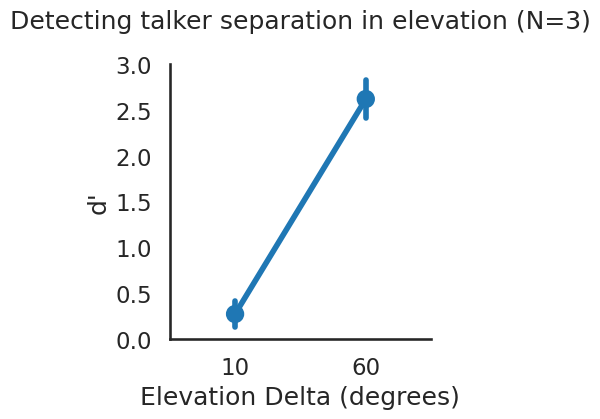

In [200]:
d_prime_df = pd.DataFrame(d_prime)
# plot 
sns.set_context('talk')
sns.set_style('white')
g = sns.catplot(data=d_prime_df, kind='point', x='elev_delta', y='d_prime', aspect=1, height=4, errorbar='se')
g.set_axis_labels('Elevation Delta (degrees)', 'd\'')
g.set(ylim=(0, 3))
plt.title('Detecting talker separation in elevation (N=3)', y=1.1)



### Direction difference 

In [186]:
##### Look at percent correct 
direction_trials = results_df[results_df.task == 'direction'].copy()
direction_trials['cue_azim'], direction_trials['cue_elev'] = zip(*direction_trials['target_loc'].apply(lambda x: x[0]))
direction_trials['elev_delta_rel'] =  direction_trials['distractor_elev'] - direction_trials['target_elev']
direction_summary = direction_trials.groupby(['participant',  'cue_elev', 'elev_delta_rel',  'target_elev', 'elev_delta']).correct.mean().reset_index()

Text(0.5, 1.1, 'Report elevation direction (N=3)')

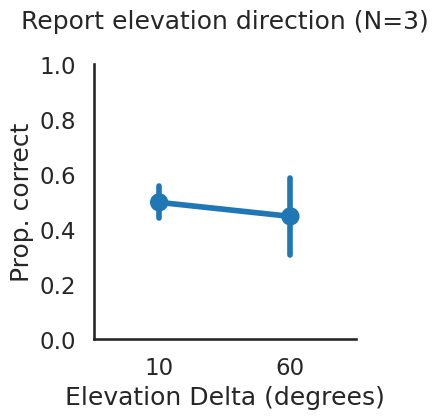

In [194]:
# Plot summary 
sns.set_context('talk')
sns.set_style('white')
g = sns.catplot(data=direction_summary, kind='point', x='elev_delta', y='correct',  aspect=1, height=4, errorbar='se')
g.set_axis_labels('Elevation Delta (degrees)', 'Prop. correct')
g.set(ylim=(0, 1))
plt.title('Report elevation direction (N=3)', y=1.1)


In [203]:
direction_summary[direction_summary['elev_delta'] == 60].correct.mean()

0.4460517902813299

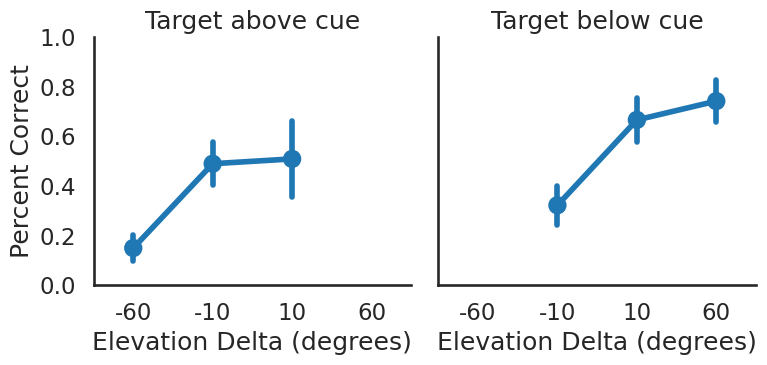

In [188]:
# Plot summary 
sns.set_context('talk')
sns.set_style('white')
direction_summary['loc_re_cue'] = (direction_summary['target_elev'] > direction_summary['cue_elev']).astype('int')

direction_summary['loc_re_cue'] = direction_summary['loc_re_cue'].replace({0: 'Target below cue', 1: 'Target above cue'})
g = sns.catplot(data=direction_summary, kind='point', x='elev_delta_rel', y='correct', col='loc_re_cue', aspect=1, height=4, errorbar='se')
g.set_axis_labels('Elevation Delta (degrees)', 'Percent Correct')
g.set_titles('{col_name}')
g.set(ylim=(0, 1))
